# DFT clustering energy comparison

Compares clustered and dispersed solute configurations in a 54-atom BCC Fe supercell.

Only `numpy` and `matplotlib` are used.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Total energies

The energy difference is defined as

`Delta E = E_clustered - E_dispersed`.

A positive value means the dispersed configuration is lower in energy and therefore more stable.

In [2]:
ry_to_mev = 13605.7

energies_ry = {
    "fe54_pure": -13379.23285,
    "fe54_3ni_clustered": -13654.31167,
    "fe54_3ni_dispersed": -13654.32355,
    "fe54_5mo_clustered": -12837.86584,
    "fe54_5mo_dispersed": -12837.95000,
}

systems = ["Ni", "Mo"]
delta_e_ry = np.array([
    energies_ry["fe54_3ni_clustered"] - energies_ry["fe54_3ni_dispersed"],
    energies_ry["fe54_5mo_clustered"] - energies_ry["fe54_5mo_dispersed"],
])
delta_e_mev = delta_e_ry * ry_to_mev

for system, d_ry, d_mev in zip(systems, delta_e_ry, delta_e_mev):
    print(f"{system}: Delta E = {d_ry:.5f} Ry = {d_mev:.1f} meV")

Ni: Delta E = 0.01188 Ry = 161.6 meV
Mo: Delta E = 0.08416 Ry = 1145.1 meV


## Bar chart

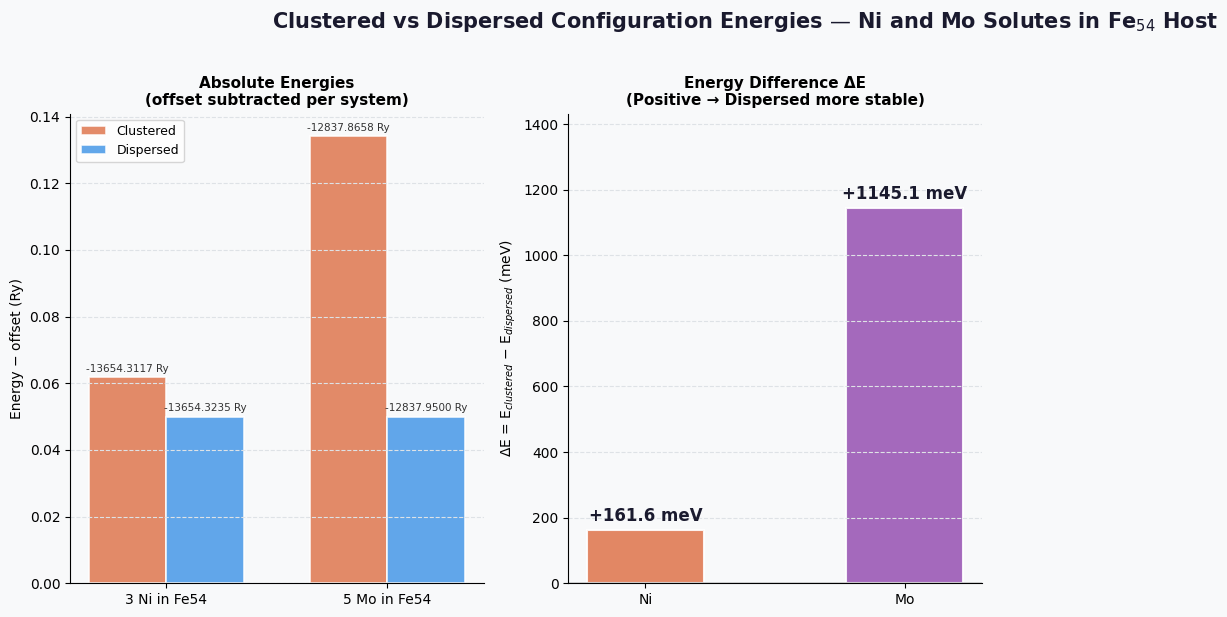

✅  Saved → energy_comparison.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
systems      = ["3 Ni in Fe54", "5 Mo in Fe54"]
e_clustered  = [-13654.31167, -12837.86584]   # Ry
e_dispersed  = [-13654.32355, -12837.95000]   # Ry
delta_e_meV  = [161.6, 1145.1]                # meV

labels_short = ["Ni", "Mo"]

# ── Colour palette ────────────────────────────────────────────────────────────
C_CLUSTER  = "#E07B54"
C_DISPERSE = "#4C9BE8"
BG         = "#F8F9FA"
GRID       = "#DEE2E6"

fig = plt.figure(figsize=(15, 6), facecolor=BG)
fig.suptitle(
    "Clustered vs Dispersed Configuration Energies — Ni and Mo Solutes in Fe$_{54}$ Host",
    fontsize=15, fontweight="bold", y=1.02, color="#1A1A2E"
)

# ══════════════════════════════════════════════════════════════════════════════
# Panel 1 — Grouped bar chart (absolute energies, shifted per system)
# ══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_facecolor(BG)

x = np.arange(len(systems))
w = 0.35

offsets    = [min(e_clustered[i], e_dispersed[i]) - 0.05 for i in range(len(systems))]
ec_shifted = [e_clustered[i] - offsets[i] for i in range(len(systems))]
ed_shifted = [e_dispersed[i] - offsets[i] for i in range(len(systems))]

b1 = ax1.bar(x - w/2, ec_shifted, w, label="Clustered", color=C_CLUSTER,  alpha=0.88, edgecolor="white", linewidth=1.2)
b2 = ax1.bar(x + w/2, ed_shifted, w, label="Dispersed", color=C_DISPERSE, alpha=0.88, edgecolor="white", linewidth=1.2)

ax1.set_xticks(x)
ax1.set_xticklabels(systems, fontsize=10)
ax1.set_ylabel("Energy − offset (Ry)", fontsize=10)
ax1.set_title("Absolute Energies\n(offset subtracted per system)", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", color=GRID, linestyle="--", linewidth=0.8)
ax1.spines[["top","right"]].set_visible(False)

for rect, val in zip(b1.patches, e_clustered):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.001,
             f"{val:.4f} Ry", ha="center", va="bottom", fontsize=7.5, color="#333")
for rect, val in zip(b2.patches, e_dispersed):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.001,
             f"{val:.4f} Ry", ha="center", va="bottom", fontsize=7.5, color="#333")

# ══════════════════════════════════════════════════════════════════════════════
# Panel 2 — ΔE bar chart
# ══════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_facecolor(BG)

colors_delta = ["#E07B54", "#9B59B6"]
bars = ax2.bar(labels_short, delta_e_meV, color=colors_delta, alpha=0.9,
               edgecolor="white", linewidth=1.5, width=0.45)

for bar, val in zip(bars, delta_e_meV):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f"+{val} meV", ha="center", va="bottom",
             fontsize=12, fontweight="bold", color="#1A1A2E")

ax2.set_ylabel("ΔE = E$_{clustered}$ − E$_{dispersed}$ (meV)", fontsize=10)
ax2.set_title("Energy Difference ΔE\n(Positive → Dispersed more stable)", fontsize=11, fontweight="bold")
ax2.set_ylim(0, max(delta_e_meV) * 1.25)
ax2.axhline(0, color="#555", linewidth=1)
ax2.grid(axis="y", color=GRID, linestyle="--", linewidth=0.8)
ax2.spines[["top","right"]].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# Panel 3 — Summary table
# ══════════════════════════════════════════════════════════════════════════════
# ax3 = fig.add_subplot(1, 3, 3)
# ax3.set_facecolor(BG)
# ax3.axis("off")

table_data = [
    ["System",        "E Clustered (Ry)", "E Dispersed (Ry)", "ΔE (meV)", "More Stable"],
    ["3 Ni in Fe₅₄", "-13654.31167",     "-13654.32355",     "+161.6",   "Dispersed ✓"],
    ["5 Mo in Fe₅₄", "-12837.86584",     "-12837.95000",     "+1145.1",  "Dispersed ✓"],
]

col_widths  = [0.20, 0.22, 0.22, 0.16, 0.20]
row_colors  = [["#2C3E50"]*5, [BG]*5, [BG]*5]
text_colors = [["white"]*5,   ["#333"]*5, ["#333"]*5]
y_positions = [0.78, 0.50, 0.22]
x_starts    = [0.02, 0.22, 0.44, 0.66, 0.82]

for ri, (row, yp, rc, tc) in enumerate(zip(table_data, y_positions, row_colors, text_colors)):
    for ci, (cell, xp, cw, fc, tcolor) in enumerate(zip(row, x_starts, col_widths, rc, tc)):
        ax3.text(xp + cw/2, yp, cell,
                 ha="center", va="center",
                 fontsize=8.5 if ri > 0 else 9,
                 fontweight="bold" if ri == 0 else "normal",
                 color=tcolor,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor=fc, edgecolor="#CCC", linewidth=0.8),
                 transform=ax3.transAxes)

# ax3.set_title("Summary Table", fontsize=11, fontweight="bold")
# ax3.text(0.5, 0.05,
#          "➜  Dispersed state is energetically preferred at 0 K for both solutes.\n"
#          "    Clustering must be driven by thermal activation at elevated temperature.",
#          ha="center", va="center", fontsize=8.5,
#          color="#1A4971", style="italic",
#          bbox=dict(boxstyle="round,pad=0.5", facecolor="#D6EAF8", edgecolor="#AED6F1"),
#          transform=ax3.transAxes)

# ── Final layout ──────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("../../energy_comparison.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("✅  Saved → energy_comparison.png")

## Interpretation

Both systems have positive `Delta E`, so the dispersed solute configurations are lower in energy than the clustered configurations.

Therefore, clustering requires thermal activation at 480 degC, supporting Li et al.'s kinetic precipitation sequence.